In [1]:
import sys
sys.path.insert(0, "/Users/matt.holden/Projects/tennis-origination")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from injestion.core.bq import get_client
from injestion.sportradar import SportradarManager
from injestion.oddsjam import OddsJamManager
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
bq_client = get_client()
sr_manager = SportradarManager()
oj_manager = OddsJamManager()

________
### Retrieve Data

In [3]:
def get_pbp_data() -> pd.DataFrame:
    event_timeline_table_id = sr_manager.get_table_id("event_timeline")
    query = f"""
    SELECT * FROM `{event_timeline_table_id}`
    """
    return bq_client.query(query).to_dataframe()

pbp = get_pbp_data()
pbp = pbp[~pbp.timeline_not_available]

In [4]:
def get_event_summary_data() -> pd.DataFrame:
    event_summary_table_id = sr_manager.get_table_id("event_summary")
    query = f"""
    SELECT * FROM `{event_summary_table_id}`
    """
    return bq_client.query(query).to_dataframe()

event_summary = get_event_summary_data()

event_summary["total_sets"] = event_summary["home_score"] + event_summary["away_score"]

In [5]:
def get_event_statistics_data() -> pd.DataFrame:
    event_statistics_table_id = sr_manager.get_table_id("event_statistics")
    query = f"""
    SELECT * FROM `{event_statistics_table_id}`
    """
    return bq_client.query(query).to_dataframe()

event_statistics = get_event_statistics_data()

_________

Merge with event_summary to get player names into play by play

In [6]:
pbp_with_server = pbp.merge(
    event_summary[["sport_event_id", "total_sets", "mode_best_of", "home_competitor_id", "away_competitor_id", "home_competitor_name", "away_competitor_name", "match_status"]], on="sport_event_id", how="left"
)

# server competitor name
pbp_with_server["server_competitor_name"] = np.where(
    pbp_with_server["server"] == "home",  # use your actual column name
    pbp_with_server["home_competitor_name"],
    np.where(
        pbp_with_server["server"] == "away",
        pbp_with_server["away_competitor_name"],
        None,
    ),
)

# server competitor id
pbp_with_server["server_competitor_id"] = np.where(
    pbp_with_server["server"] == "home",
    pbp_with_server["home_competitor_id"],
    np.where(
        pbp_with_server["server"] == "away",
        pbp_with_server["away_competitor_id"],
        None,
    ),
)



Assign set numbers (period) and also remove incomplete/compromised data

In [7]:
def assign_set_from_period_starts(match_timeline: pd.DataFrame) -> pd.Series:
    """Assign set number (period) to each event. One match's rows only."""
    df = match_timeline.sort_values("event_order")
    current_period = None
    started = False
    ended = False
    suspended = False
    periods = []
    for _, row in df.iterrows():
        if row["type"] == "match_started":
            started = True
            periods.append(None)
        elif row["type"] == "match_ended":
            periods.append(None)
            ended = True
        elif not started or ended:
            periods.append(None)
        elif row["type"] == "match_suspended":
            suspended = True
            periods.append(current_period if current_period is None else int(current_period))
        elif suspended and row["type"] == "period_start":
            suspended = False
            periods.append(current_period if current_period is None else int(current_period))
        elif row["type"] == "period_start":
            current_period = (current_period + 1) if current_period is not None else 1
            periods.append(current_period)
        else:
            periods.append(current_period if current_period is None else int(current_period))
    return pd.Series(periods, index=df.index)

def assign_set_from_period_scores(match_timeline: pd.DataFrame) -> pd.Series:
    """
    Infer set number from period_score events only. Use when period_start is missing.
    Only events between match_started and match_ended (inclusive) get a period;
    events before match_started or after match_ended get None.
    A period_score row is the last point of the set; the next row starts the new set.
    """
    df = match_timeline.sort_values("event_order")
    current_period = None
    started = False
    ended = False
    periods = []
    for _, row in df.iterrows():
        if row["type"] == "match_started":
            started = True
            current_period = 1
            periods.append(None)
        elif row["type"] == "match_ended":
            periods.append(None)
            ended = True
        elif not started or ended:
            periods.append(None)
        else:
            periods.append(int(current_period))
            if row["type"] == "period_score":
                h, a = row.get("home_score"), row.get("away_score")
                if pd.notna(h) and pd.notna(a):
                    if max(h, a) == 7 or (max(h, a) == 6 and abs(h - a) >= 2):
                        current_period += 1
    return pd.Series(periods, index=df.index)

def assign_set_null(match_timeline: pd.DataFrame) -> pd.Series:
    return pd.Series(None, index=match_timeline.index)

def assign_set(match_timeline: pd.DataFrame, total_sets: int | None) -> pd.Series:
    if pd.isna(total_sets):
        period_series = assign_set_null(match_timeline)
    else:
        period_series = assign_set_from_period_starts(match_timeline)
        sport_event_id = match_timeline["sport_event_id"].iloc[0]
        if total_sets is not None:
            max_period = period_series.max()
            if pd.isna(max_period) or max_period != total_sets:
                period_series = assign_set_from_period_scores(match_timeline)
                max_period = period_series.max()
                if pd.isna(max_period) or max_period != total_sets:
                    print(f"Failed to assign set for sport_event_id: {sport_event_id}, max_period: {max_period}, total_sets: {total_sets}")
                    period_series = assign_set_null(match_timeline)
    return period_series


In [8]:
pbp_with_server_sorted = pbp_with_server.sort_values(["sport_event_id", "event_order"])

pbp_with_server_sorted_with_period = pbp_with_server_sorted[pbp_with_server_sorted["match_status"] != "retired"]

# building period column by sport_event_id
parts = []
for sid, grp in pbp_with_server_sorted_with_period.groupby("sport_event_id", sort=False):
    total_sets = grp["total_sets"].iloc[0] if "total_sets" in grp.columns else None
    total_sets = int(total_sets) if pd.notna(total_sets) else None
    parts.append(assign_set(grp, total_sets=total_sets))
period_series = pd.concat(parts)
pbp_with_server_sorted_with_period["period"] = period_series

# remove rows where period is not assigned
pbp_with_server_sorted_with_period = pbp_with_server_sorted_with_period[
    pbp_with_server_sorted_with_period.groupby("sport_event_id")["period"].transform(lambda s: s.notna().any())
]

Failed to assign set for sport_event_id: sr:sport_event:58856555, max_period: 1.0, total_sets: 2
Failed to assign set for sport_event_id: sr:sport_event:59152417, max_period: nan, total_sets: 3
Failed to assign set for sport_event_id: sr:sport_event:59276549, max_period: nan, total_sets: 2
Failed to assign set for sport_event_id: sr:sport_event:59410453, max_period: nan, total_sets: 3
Failed to assign set for sport_event_id: sr:sport_event:59521813, max_period: nan, total_sets: 2
Failed to assign set for sport_event_id: sr:sport_event:59816634, max_period: nan, total_sets: 2
Failed to assign set for sport_event_id: sr:sport_event:61073927, max_period: nan, total_sets: 2
Failed to assign set for sport_event_id: sr:sport_event:61213687, max_period: nan, total_sets: 3
Failed to assign set for sport_event_id: sr:sport_event:62476956, max_period: 3.0, total_sets: 2
Failed to assign set for sport_event_id: sr:sport_event:62477534, max_period: 4.0, total_sets: 3
Failed to assign set for sport

/var/folders/wj/3h07_z2d5xg4t2fzhqx3f0j00000gp/T/ipykernel_77873/4080144520.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pbp_with_server_sorted_with_period["period"] = period_series


_______

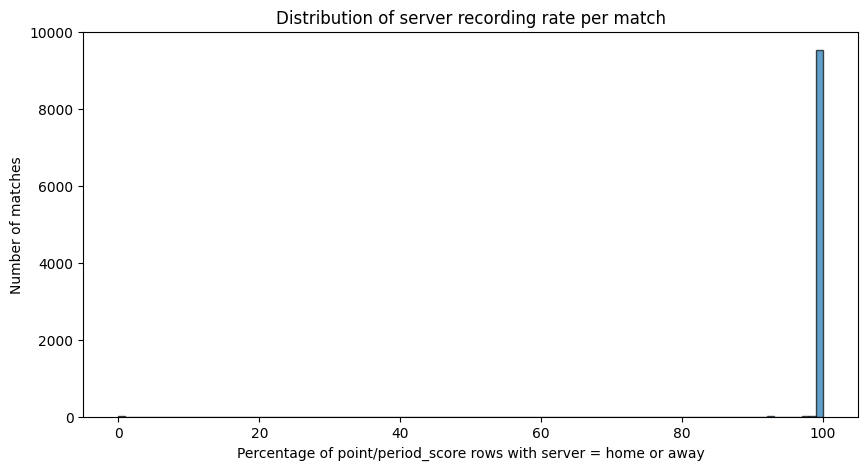

In [9]:
# Restrict to rows where we expect server to be recorded
pbp_points = pbp_with_server_sorted_with_period[
    pbp_with_server_sorted_with_period["type"].isin(["point", "period_score"])
]

# Per-match: % of those rows where server is "home" or "away"
pct_per_match = (
    pbp_points
    .groupby("sport_event_id", sort=False)
    .apply(
        lambda g: (g["server"].isin(["home", "away"]).sum() / len(g) * 100) if len(g) else np.nan,
        include_groups=False,
    )
)
pct_per_match = pct_per_match.dropna()

# Histogram
plt.figure(figsize=(10, 5))
plt.hist(pct_per_match, bins=100, edgecolor="black", alpha=0.7)
plt.xlabel("Percentage of point/period_score rows with server = home or away")
plt.ylabel("Number of matches")
plt.title("Distribution of server recording rate per match")
plt.show()

In [10]:
# Match IDs where 100% of point/period_score rows have server = home or away
match_ids_full_server = pct_per_match[pct_per_match >= 100].index

# Restrict dataframe to those matches
pbp_with_server_sorted_with_period = pbp_with_server_sorted_with_period[
    pbp_with_server_sorted_with_period["sport_event_id"].isin(match_ids_full_server)
]

______

Calculate 1st serve percentage for each competitor/match combo

In [11]:
sample_match = pbp_with_server_sorted_with_period[pbp_with_server_sorted_with_period['sport_event_id'] == 'sr:sport_event:64433631'].sort_values(by='event_order')

In [51]:
def get_serve_stats(sample_match):

    # Competitor ids from first row
    home_id = sample_match["home_competitor_id"].iloc[0]
    away_id = sample_match["away_competitor_id"].iloc[0]

    # Masks: valid server, first serve in (not explicitly a fault)
    valid = sample_match["server"].notna()
    ff = sample_match["first_serve_fault"]
    first_serve_in_mask = (ff != True) | ff.isna()

    # Second serve: attempt = first serve fault; in = not a double fault
    first_serve_fault_mask = ff == True
    second_serve_in_mask = sample_match["result"] != "double_fault"

    home_mask = (sample_match["server"] == "home") & valid
    away_mask = (sample_match["server"] == "away") & valid

    # Double Fault Anamoly
    double_fault_mask = sample_match["result"] == "double_fault"
    inconsistent_serve_fault_mask = double_fault_mask & first_serve_in_mask
    if inconsistent_serve_fault_mask.any():
        return None, None


    # ---- Match level: first serve ----
    match_first_attempts = {home_id: home_mask.sum(), away_id: away_mask.sum()}
    match_first_in = {
        home_id: (home_mask & first_serve_in_mask).sum(),
        away_id: (away_mask & first_serve_in_mask).sum(),
    }

    # ---- Match level: second serve ----
    home_second_mask = home_mask & first_serve_fault_mask
    away_second_mask = away_mask & first_serve_fault_mask
    match_second_attempts = {home_id: home_second_mask.sum(), away_id: away_second_mask.sum()}
    match_second_in = {
        home_id: (home_second_mask & second_serve_in_mask).sum(),
        away_id: (away_second_mask & second_serve_in_mask).sum(),
    }

    def pct(attempts, in_count):
        return in_count / attempts if attempts else None

    server_percentage_by_match = {
        home_id: {
            "first_serve_attempts": int(match_first_attempts[home_id]),
            "first_serve_in": int(match_first_in[home_id]),
            "first_serve_percentage": pct(match_first_attempts[home_id], match_first_in[home_id]),
            "second_serve_attempts": int(match_second_attempts[home_id]),
            "second_serve_in": int(match_second_in[home_id]),
            "second_serve_percentage": pct(match_second_attempts[home_id], match_second_in[home_id]),
        },
        away_id: {
            "first_serve_attempts": int(match_first_attempts[away_id]),
            "first_serve_in": int(match_first_in[away_id]),
            "first_serve_percentage": pct(match_first_attempts[away_id], match_first_in[away_id]),
            "second_serve_attempts": int(match_second_attempts[away_id]),
            "second_serve_in": int(match_second_in[away_id]),
            "second_serve_percentage": pct(match_second_attempts[away_id], match_second_in[away_id]),
        },
    }

    # ---- Set level (only rows with valid numeric period) ----
    df_valid = sample_match.loc[valid & sample_match["period"].notna()].copy()
    df_valid["first_serve_in_flag"] = (df_valid["first_serve_fault"] != True) | df_valid["first_serve_fault"].isna()
    df_valid["second_serve_attempt_flag"] = df_valid["first_serve_fault"] == True
    df_valid["second_serve_in_flag"] = df_valid["result"] != "double_fault"

    def set_level_stats(server_val: str, competitor_id):
        sub = df_valid[df_valid["server"] == server_val]
        if sub.empty:
            return {}
        def agg_per_period(g):
            first_attempts = len(g)
            first_in = ((g["first_serve_fault"] != True) | g["first_serve_fault"].isna()).sum()
            second_attempts = (g["first_serve_fault"] == True).sum()
            second_in = ((g["first_serve_fault"] == True) & (g["result"] != "double_fault")).sum()
            return pd.Series({
                "first_serve_attempts": first_attempts,
                "first_serve_in": first_in,
                "second_serve_attempts": second_attempts,
                "second_serve_in": second_in,
            })
        grp = sub.groupby("period", sort=True).apply(agg_per_period, include_groups=False)
        return {
            int(period): {
                "first_serve_attempts": int(row["first_serve_attempts"]),
                "first_serve_in": int(row["first_serve_in"]),
                "first_serve_percentage": pct(row["first_serve_attempts"], row["first_serve_in"]),
                "second_serve_attempts": int(row["second_serve_attempts"]),
                "second_serve_in": int(row["second_serve_in"]),
                "second_serve_percentage": pct(row["second_serve_attempts"], row["second_serve_in"]),
            }
            for period, row in grp.iterrows()
        }

    server_percentage_by_set = {
        home_id: set_level_stats("home", home_id),
        away_id: set_level_stats("away", away_id),
    }

    return server_percentage_by_match, server_percentage_by_set


In [52]:
def serve_stats_to_row(
    sport_event_id,
    server_percentage: dict,
    server_percentage_by_set: dict,
    max_sets: int = 5,
) -> pd.DataFrame:
    """
    Flatten match-level and set-level serve stats to one row per competitor.
    Unique key: (sport_event_id, competitor_id). Set columns 1..max_sets; missing sets are null.
    """
    match_cols = [
        "first_serve_attempts", "first_serve_in", "first_serve_percentage",
        "second_serve_attempts", "second_serve_in", "second_serve_percentage",
    ]
    set_cols = [
        "first_serve_attempts", "first_serve_in", "first_serve_percentage",
        "second_serve_attempts", "second_serve_in", "second_serve_percentage",
    ]
    rows = []
    for competitor_id, match_stats in server_percentage.items():
        row = {
            "sport_event_id": sport_event_id,
            "competitor_id": competitor_id,
        }
        for c in match_cols:
            row[c] = match_stats.get(c)
        set_stats = server_percentage_by_set.get(competitor_id) or {}
        for s in range(1, max_sets + 1):
            st = set_stats.get(s)
            for c in set_cols:
                key = f"set_{s}_{c}"
                row[key] = st[c] if st else None
        rows.append(row)
    return pd.DataFrame(rows)


# Build tabular form for this match (sport_event_id from sample_match)
sport_event_id = sample_match["sport_event_id"].iloc[0]
server_percentage_by_match, server_percentage_by_set = get_serve_stats(sample_match)
serve_stats_table = serve_stats_to_row(
    sport_event_id,
    server_percentage_by_match,
    server_percentage_by_set,
    max_sets=5,
)
serve_stats_table

,sport_event_id,competitor_id,first_serve_attempts,first_serve_in,first_serve_percentage,second_serve_attempts,second_serve_in,second_serve_percentage,set_1_first_serve_attempts,set_1_first_serve_in,set_1_first_serve_percentage,set_1_second_serve_attempts,set_1_second_serve_in,set_1_second_serve_percentage,set_2_first_serve_attempts,set_2_first_serve_in,set_2_first_serve_percentage,set_2_second_serve_attempts,set_2_second_serve_in,set_2_second_serve_percentage,set_3_first_serve_attempts,set_3_first_serve_in,set_3_first_serve_percentage,set_3_second_serve_attempts,set_3_second_serve_in,set_3_second_serve_percentage,set_4_first_serve_attempts,set_4_first_serve_in,set_4_first_serve_percentage,set_4_second_serve_attempts,set_4_second_serve_in,set_4_second_serve_percentage,set_5_first_serve_attempts,set_5_first_serve_in,set_5_first_serve_percentage,set_5_second_serve_attempts,set_5_second_serve_in,set_5_second_serve_percentage
0,sr:sport_event:64433631,sr:competitor:788260,61,38,0.622951,23,20,0.869565,25,18,0.720000,7,6,0.857143,28,18,0.642857,10,9,0.9,8,2,0.25,6,5,0.833333,None,None,None,None,None,None,None,None,None,None,None,None
1,sr:sport_event:64433631,sr:competitor:1186389,54,36,0.666667,18,17,0.944444,28,15,0.535714,13,13,1.000000,17,12,0.705882,5,4,0.8,9,9,1.00,0,0,NaN,None,None,None,None,None,None,None,None,None,None,None,None


In [53]:
# Example when you have a list of matches / (server_percentage, server_percentage_by_set) per match
def process_match(g):
    """Process one match group: compute serve stats and return tabular rows (one per competitor)."""
    sid = g.name  # group key = sport_event_id
    server_percentage_by_match, server_percentage_by_set = get_serve_stats(g)
    if server_percentage_by_match is None:
        return pd.DataFrame()
    return serve_stats_to_row(sid, server_percentage_by_match, server_percentage_by_set)

serve_stats_table = (
    pbp_with_server_sorted_with_period
    .groupby("sport_event_id", sort=False)
    .apply(process_match)
    .reset_index(drop=True)
)

/var/folders/wj/3h07_z2d5xg4t2fzhqx3f0j00000gp/T/ipykernel_77873/905815988.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  .apply(process_match)
/var/folders/wj/3h07_z2d5xg4t2fzhqx3f0j00000gp/T/ipykernel_77873/905815988.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(process_match)


In [15]:
serve_stats_table.sample()

,sport_event_id,competitor_id,first_serve_attempts,first_serve_in,first_serve_percentage,second_serve_attempts,second_serve_in,second_serve_percentage,set_1_first_serve_attempts,set_1_first_serve_in,set_1_first_serve_percentage,set_1_second_serve_attempts,set_1_second_serve_in,set_1_second_serve_percentage,set_2_first_serve_attempts,set_2_first_serve_in,set_2_first_serve_percentage,set_2_second_serve_attempts,set_2_second_serve_in,set_2_second_serve_percentage,set_3_first_serve_attempts,set_3_first_serve_in,set_3_first_serve_percentage,set_3_second_serve_attempts,set_3_second_serve_in,set_3_second_serve_percentage,set_4_first_serve_attempts,set_4_first_serve_in,set_4_first_serve_percentage,set_4_second_serve_attempts,set_4_second_serve_in,set_4_second_serve_percentage,set_5_first_serve_attempts,set_5_first_serve_in,set_5_first_serve_percentage,set_5_second_serve_attempts,set_5_second_serve_in,set_5_second_serve_percentage
6876,sr:sport_event:61428121,sr:competitor:341112,93,67,0.72043,26,24,0.923077,36,21,0.583333,15,13,0.866667,26,20,0.769231,6,6,1.0,31,26,0.83871,5,5,1.0,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN


In [39]:
serve_stats_table[serve_stats_table['first_serve_attempts'] < 24]

,sport_event_id,competitor_id,first_serve_attempts,first_serve_in,first_serve_percentage,second_serve_attempts,second_serve_in,second_serve_percentage,set_1_first_serve_attempts,set_1_first_serve_in,set_1_first_serve_percentage,set_1_second_serve_attempts,set_1_second_serve_in,set_1_second_serve_percentage,set_2_first_serve_attempts,set_2_first_serve_in,set_2_first_serve_percentage,set_2_second_serve_attempts,set_2_second_serve_in,set_2_second_serve_percentage,set_3_first_serve_attempts,set_3_first_serve_in,set_3_first_serve_percentage,set_3_second_serve_attempts,set_3_second_serve_in,set_3_second_serve_percentage,set_4_first_serve_attempts,set_4_first_serve_in,set_4_first_serve_percentage,set_4_second_serve_attempts,set_4_second_serve_in,set_4_second_serve_percentage,set_5_first_serve_attempts,set_5_first_serve_in,set_5_first_serve_percentage,set_5_second_serve_attempts,set_5_second_serve_in,set_5_second_serve_percentage


The minimum first serve attempts in a game is 24, data has been properly cleaned to remove those matches

________

In [54]:
serve_stats_table['competitor_id'].nunique()

2086

In [55]:
serve_stats_table['sport_event_id'].nunique()

8309

__________

### Feature Engineering
The per match serving percentages have been calculated. Now we need to investigate other features that might be relevant for predicting serve percentage.

Ideally, this is data aggreagated at the player level and match level so it can be ingested per match/player as tabular data.

Options for features:

Player Baseline:
- Server historical serve percentage
- Rolling first-serve percentage
- First-serve percentage on surface
- std or range of first-serve % in last N matches (5)
- server serving strength (elo) (might indicate more control over serve, adjusting serve for different players)
- Number of matches in last 7 days (fatigue)
    - Adjust fatigue for length of matches**** HSDB
- Aces per match
- First serve win percentage
- Player height

Tournament Conditions (all of these are weird and would require information about the match outside of consensus)
    **Should be able to get tournament ID which we would be able to aggregate stats from**
- Indoor/Outdoor 
- Tournament historical serve percentage relative to overall player median
- Round of Tournament (R1, Quarter, Final, etc)
- Best of 3 or 5
- Court Type (Clay, Hard Court, Grass)

Opponent:
- Returner return strength (elo)
- serve percentage allowed by returner


Tips for the long tailed behavior seen below (most players between 1-5 observations, few, but important players with up to 70 observations)

- Give the model explicit signals for high observation and low observation players raw number or binned. Or a binary indicator for if we have more than 5 observations 
- Pass mean first serve percentage for the tournament (or overall historical) as a feature so that the model can anchor low-observation players to the mean
- Pre-shrink the serve percentages passed into the model i.e. during feature engineering if we only have one match and the serve percentage was 95%, pre-process it towards the mean so that the model doesn't have to learn when to shrink towards the tournament average
- Opponent first serve percentage might be a stable indication if the opponent has a lot of observations.
    **include opponent observations in addition to player observations


<Axes: >

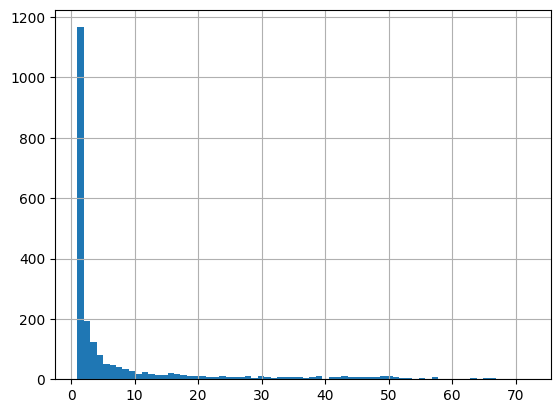

In [19]:
serve_stats_table['competitor_id'].value_counts().hist(bins=70)

<Axes: >

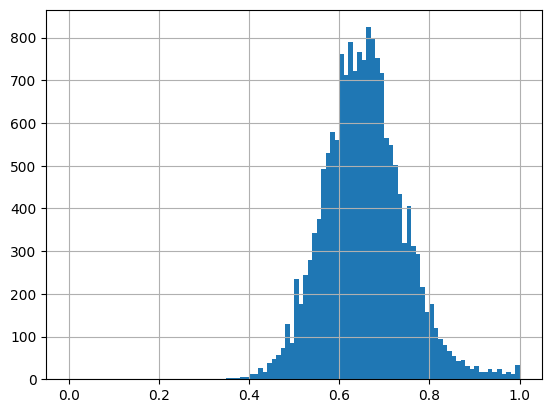

In [56]:
serve_stats_table['first_serve_percentage'].hist(
    bins=np.linspace(0, 1, 101),  # 100 bins, width 0.01
)

________________________
Investigating the descrepancy found between serve stats table and event statistics

In [21]:
serve_stats_table[serve_stats_table['first_serve_percentage'] != 1].sample()

,sport_event_id,competitor_id,first_serve_attempts,first_serve_in,first_serve_percentage,second_serve_attempts,second_serve_in,second_serve_percentage,set_1_first_serve_attempts,set_1_first_serve_in,set_1_first_serve_percentage,set_1_second_serve_attempts,set_1_second_serve_in,set_1_second_serve_percentage,set_2_first_serve_attempts,set_2_first_serve_in,set_2_first_serve_percentage,set_2_second_serve_attempts,set_2_second_serve_in,set_2_second_serve_percentage,set_3_first_serve_attempts,set_3_first_serve_in,set_3_first_serve_percentage,set_3_second_serve_attempts,set_3_second_serve_in,set_3_second_serve_percentage,set_4_first_serve_attempts,set_4_first_serve_in,set_4_first_serve_percentage,set_4_second_serve_attempts,set_4_second_serve_in,set_4_second_serve_percentage,set_5_first_serve_attempts,set_5_first_serve_in,set_5_first_serve_percentage,set_5_second_serve_attempts,set_5_second_serve_in,set_5_second_serve_percentage
6449,sr:sport_event:61362629,sr:competitor:228418,62,39,0.629032,23,22,0.956522,24,16,0.666667,8,8,1.0,38,23,0.605263,15,14,0.933333,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN


In [22]:
serve_stats_table[serve_stats_table['sport_event_id'] == 'sr:sport_event:63782785']

,sport_event_id,competitor_id,first_serve_attempts,first_serve_in,first_serve_percentage,second_serve_attempts,second_serve_in,second_serve_percentage,set_1_first_serve_attempts,set_1_first_serve_in,set_1_first_serve_percentage,set_1_second_serve_attempts,set_1_second_serve_in,set_1_second_serve_percentage,set_2_first_serve_attempts,set_2_first_serve_in,set_2_first_serve_percentage,set_2_second_serve_attempts,set_2_second_serve_in,set_2_second_serve_percentage,set_3_first_serve_attempts,set_3_first_serve_in,set_3_first_serve_percentage,set_3_second_serve_attempts,set_3_second_serve_in,set_3_second_serve_percentage,set_4_first_serve_attempts,set_4_first_serve_in,set_4_first_serve_percentage,set_4_second_serve_attempts,set_4_second_serve_in,set_4_second_serve_percentage,set_5_first_serve_attempts,set_5_first_serve_in,set_5_first_serve_percentage,set_5_second_serve_attempts,set_5_second_serve_in,set_5_second_serve_percentage
11978,sr:sport_event:63782785,sr:competitor:399633,61,36,0.590164,25,22,0.880000,32,19,0.593750,13,11,0.846154,29,17,0.586207,12,11,0.916667,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN
11979,sr:sport_event:63782785,sr:competitor:722429,53,32,0.603774,21,19,0.904762,28,16,0.571429,12,11,0.916667,25,16,0.640000,9,8,0.888889,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN


In [23]:
event_statistics[event_statistics['sport_event_id'] == 'sr:sport_event:63782785']

,sport_event_id,competitor_id,qualifier,aces,breakpoints_won,double_faults,first_serve_points_won,first_serve_successful,games_won,max_games_in_a_row,max_points_in_a_row,points_won,points_won_from_last_10,second_serve_points_won,second_serve_successful,service_games_won,service_points_lost,service_points_won,tiebreaks_won,total_breakpoints,backhand_errors,backhand_unforced_errors,backhand_winners,drop_shot_unforced_errors,drop_shot_winners,forehand_errors,forehand_unforced_errors,forehand_winners,groundstroke_errors,groundstroke_unforced_errors,groundstroke_winners,lob_unforced_errors,lob_winners,overhead_stroke_errors,overhead_stroke_unforced_errors,overhead_stroke_winners,return_errors,return_winners,volley_unforced_errors,volley_winners,statistics_not_available
12632,sr:sport_event:63782785,sr:competitor:399633,home,3,0,3,23,36,7,1,6,52,3,13,22,6,25,36,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False
12633,sr:sport_event:63782785,sr:competitor:722429,away,3,3,2,27,32,12,4,4,62,7,10,19,9,16,37,0,6,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False


In [24]:
event_summary[event_summary['sport_event_id'] == 'sr:sport_event:60344611']

,sport_event_id,generated_at,start_time,start_time_confirmed,sport_id,category_id,category_name,competition_id,competition_name,competition_parent_id,competition_type,competition_gender,competition_level,season_id,season_name,stage_order,stage_type,stage_phase,stage_start_date,stage_end_date,stage_year,round_name,round_number,mode_best_of,coverage_enhanced_stats,coverage_detailed_serve_outcomes,coverage_play_by_play,home_competitor_id,away_competitor_id,home_competitor_name,away_competitor_name,home_competitor_seed,away_competitor_seed,venue_id,venue_name,venue_city,venue_country_name,venue_country_code,venue_timezone,match_status,home_score,away_score,winner_id,period_scores,total_sets
5801,sr:sport_event:60344611,2026-02-27 20:39:08+00:00,2025-05-05 17:05:00+00:00,True,sr:sport:5,sr:category:6,WTA,sr:competition:4775,"WTA Rome, Italy Women Singles",sr:competition:4773,singles,women,wta_1000,sr:season:124167,"WTA Rome, Italy Women Singles 2025",1,cup,qualification,2025-05-05,2025-05-06,2025,qualification_round_1,1,3,False,True,True,sr:competitor:18808,sr:competitor:150574,"Cornet, Alize","Bondar, Anna",<NA>,22,sr:venue:82505,Court 14,Rome,Italy,ITA,Europe/Rome,ended,0,2,sr:competitor:150574,"[{""home_score"": 4, ""away_score"": 6, ""type"": ""s...",2


In [57]:
es_cols = event_statistics[
    ["sport_event_id", "competitor_id", "first_serve_successful", "second_serve_successful"]
]

alignment_check = serve_stats_table.merge(
    es_cols,
    on=["sport_event_id", "competitor_id"],
    how="inner",
    validate="one_to_one",  # drop if not 1:1 per key
)

def cols_equal(s1, s2):
    """True where values match, including both NaN."""
    return (s1 == s2) | (s1.isna() & s2.isna())

first_ok = cols_equal(alignment_check["first_serve_in"], alignment_check["first_serve_successful"])
second_ok = cols_equal(alignment_check["second_serve_in"], alignment_check["second_serve_successful"])
row_aligned = first_ok & second_ok
alignment_check = alignment_check.assign(row_aligned=row_aligned)

# Row-level (player–match)
n_rows_aligned = int(row_aligned.sum())
n_rows_misaligned = int((~row_aligned).sum())

# Match-level
match_ok = alignment_check.groupby("sport_event_id")["row_aligned"].all()
n_matches_aligned = int(match_ok.sum())
n_matches_misaligned = int((~match_ok).sum())

print("Player-match rows aligned:", n_rows_aligned, "| misaligned:", n_rows_misaligned)
print("Matches aligned:", n_matches_aligned, "| misaligned:", n_matches_misaligned)

Player-match rows aligned: 12280 | misaligned: 4308
Matches aligned: 5297 | misaligned: 3012


<Axes: >

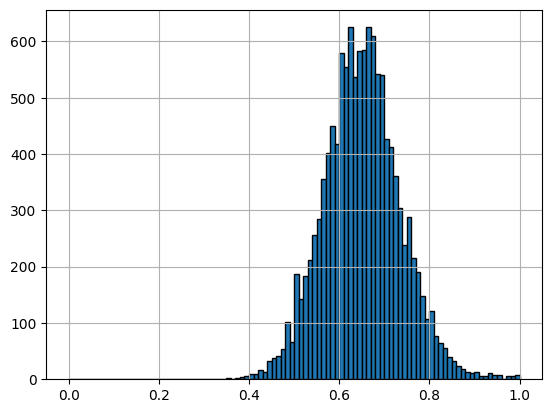

In [58]:
alignment_check.loc[alignment_check["row_aligned"], "first_serve_percentage"].hist(
    bins=np.linspace(0, 1, 101),  # 100 bins, width 0.01
    edgecolor="black",
)

In [27]:
x = alignment_check[alignment_check['row_aligned']]
x[x['first_serve_percentage'] == 1].sample()

,sport_event_id,competitor_id,first_serve_attempts,first_serve_in,first_serve_percentage,second_serve_attempts,second_serve_in,second_serve_percentage,set_1_first_serve_attempts,set_1_first_serve_in,set_1_first_serve_percentage,set_1_second_serve_attempts,set_1_second_serve_in,set_1_second_serve_percentage,set_2_first_serve_attempts,set_2_first_serve_in,set_2_first_serve_percentage,set_2_second_serve_attempts,set_2_second_serve_in,set_2_second_serve_percentage,set_3_first_serve_attempts,set_3_first_serve_in,set_3_first_serve_percentage,set_3_second_serve_attempts,set_3_second_serve_in,set_3_second_serve_percentage,set_4_first_serve_attempts,set_4_first_serve_in,set_4_first_serve_percentage,set_4_second_serve_attempts,set_4_second_serve_in,set_4_second_serve_percentage,set_5_first_serve_attempts,set_5_first_serve_in,set_5_first_serve_percentage,set_5_second_serve_attempts,set_5_second_serve_in,set_5_second_serve_percentage,first_serve_successful,second_serve_successful,row_aligned
14898,sr:sport_event:67306656,sr:competitor:45902,78,78,1.0,0,0,NaN,41,41,1.0,0,0,NaN,37,37,1.0,0,0,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,78,0,True


In [28]:
event_summary[event_summary['sport_event_id'] == 'sr:sport_event:68937692']

,sport_event_id,generated_at,start_time,start_time_confirmed,sport_id,category_id,category_name,competition_id,competition_name,competition_parent_id,competition_type,competition_gender,competition_level,season_id,season_name,stage_order,stage_type,stage_phase,stage_start_date,stage_end_date,stage_year,round_name,round_number,mode_best_of,coverage_enhanced_stats,coverage_detailed_serve_outcomes,coverage_play_by_play,home_competitor_id,away_competitor_id,home_competitor_name,away_competitor_name,home_competitor_seed,away_competitor_seed,venue_id,venue_name,venue_city,venue_country_name,venue_country_code,venue_timezone,match_status,home_score,away_score,winner_id,period_scores,total_sets
4708,sr:sport_event:68937692,2026-02-27 21:03:23+00:00,2026-02-14 09:20:00+00:00,True,sr:sport:5,sr:category:6,WTA,sr:competition:4489,"WTA Dubai, UAE Women Singles",sr:competition:4487,singles,women,wta_1000,sr:season:136033,"WTA Dubai, UAE Women Singles 2026",1,cup,qualification,2026-02-13,2026-02-14,2026,qualification_final,<NA>,3,False,True,True,sr:competitor:373354,sr:competitor:341112,"Cocciaretto, Elisabetta","Zakharova, Anastasia",5,<NA>,sr:venue:86858,New Court 1,Dubai,United Arab Emirates,ARE,Asia/Dubai,ended,2,1,sr:competitor:373354,"[{""home_score"": 6, ""away_score"": 2, ""type"": ""s...",3


___

In [32]:
temp = event_statistics.copy()
temp = temp[~temp['statistics_not_available']]

In [33]:
temp['total_serves'] = temp['service_points_won'] + temp['service_points_won']
temp['first_serve_percentage'] = temp['first_serve_successful'] / temp['total_serves']

In [35]:
temp.sample()

,sport_event_id,competitor_id,qualifier,aces,breakpoints_won,double_faults,first_serve_points_won,first_serve_successful,games_won,max_games_in_a_row,max_points_in_a_row,points_won,points_won_from_last_10,second_serve_points_won,second_serve_successful,service_games_won,service_points_lost,service_points_won,tiebreaks_won,total_breakpoints,backhand_errors,backhand_unforced_errors,backhand_winners,drop_shot_unforced_errors,drop_shot_winners,forehand_errors,forehand_unforced_errors,forehand_winners,groundstroke_errors,groundstroke_unforced_errors,groundstroke_winners,lob_unforced_errors,lob_winners,overhead_stroke_errors,overhead_stroke_unforced_errors,overhead_stroke_winners,return_errors,return_winners,volley_unforced_errors,volley_winners,statistics_not_available,total_serves,first_serve_percentage
51664,sr:sport_event:62896085,sr:competitor:341112,home,0,4,4,23,32,12,4,6,63,<NA>,11,15,8,17,34,0,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,68,0.470588


<Axes: >

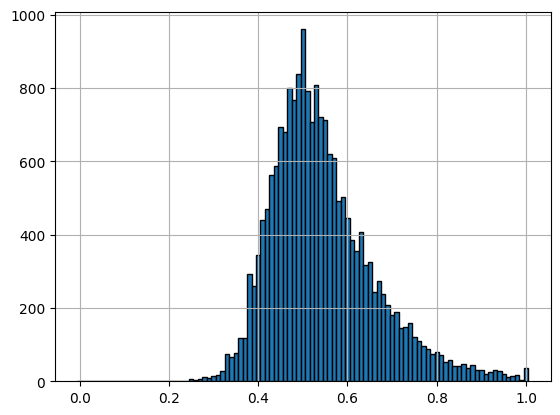

In [36]:
width = 0.01
edges = np.arange(-width / 2, 1 + width, width)  # ~[-0.005, 0.005, ..., 1.005]

temp["first_serve_percentage"].hist(bins=edges, edgecolor="black")

____________________

There's a spike at 100 and a spike near the median. Both are worth looking into. The spike at 100, looks like not all matches are tracking/logging first serve fault in the play by play. The event summary for the match below shows a different serve percentage with first serve faults aggregated. Could be an alternative method for extracting match-level serve percentages - won't be able to get set level serve percentages. The spike at ~67 is unkown right now

In [ ]:
serve_stats_table.sample()

,sport_event_id,competitor_id,first_serve_attempts,first_serve_in,first_serve_percentage,second_serve_attempts,second_serve_in,second_serve_percentage,set_1_first_serve_attempts,set_1_first_serve_in,set_1_first_serve_percentage,set_1_second_serve_attempts,set_1_second_serve_in,set_1_second_serve_percentage,set_2_first_serve_attempts,set_2_first_serve_in,set_2_first_serve_percentage,set_2_second_serve_attempts,set_2_second_serve_in,set_2_second_serve_percentage,set_3_first_serve_attempts,set_3_first_serve_in,set_3_first_serve_percentage,set_3_second_serve_attempts,set_3_second_serve_in,set_3_second_serve_percentage,set_4_first_serve_attempts,set_4_first_serve_in,set_4_first_serve_percentage,set_4_second_serve_attempts,set_4_second_serve_in,set_4_second_serve_percentage,set_5_first_serve_attempts,set_5_first_serve_in,set_5_first_serve_percentage,set_5_second_serve_attempts,set_5_second_serve_in,set_5_second_serve_percentage
16587,sr:sport_event:67817134,sr:competitor:119248,76,53,0.697368,23,21,0.913043,21,17,0.809524,4,4,1.0,27,15,0.555556,12,10,0.833333,28,21,0.75,7,7,1.0,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN


In [ ]:
event_statistics[event_statistics['sport_event_id'] == 'sr:sport_event:67674942']

,sport_event_id,competitor_id,qualifier,aces,breakpoints_won,double_faults,first_serve_points_won,first_serve_successful,games_won,max_games_in_a_row,max_points_in_a_row,points_won,points_won_from_last_10,second_serve_points_won,second_serve_successful,service_games_won,service_points_lost,service_points_won,tiebreaks_won,total_breakpoints,backhand_errors,backhand_unforced_errors,backhand_winners,drop_shot_unforced_errors,drop_shot_winners,forehand_errors,forehand_unforced_errors,forehand_winners,groundstroke_errors,groundstroke_unforced_errors,groundstroke_winners,lob_unforced_errors,lob_winners,overhead_stroke_errors,overhead_stroke_unforced_errors,overhead_stroke_winners,return_errors,return_winners,volley_unforced_errors,volley_winners,statistics_not_available
40228,sr:sport_event:67674942,sr:competitor:242602,home,1,4,2,27,49,11,3,7,70,<NA>,7,14,7,31,34,0,12,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False
40229,sr:sport_event:67674942,sr:competitor:504238,away,1,5,7,33,52,13,4,6,77,<NA>,13,23,8,36,46,0,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False


In [ ]:
serve_stats_table[serve_stats_table['sport_event_id'] == 'sr:sport_event:67674942']

,sport_event_id,competitor_id,first_serve_attempts,first_serve_in,first_serve_percentage,second_serve_attempts,second_serve_in,second_serve_percentage,set_1_first_serve_attempts,set_1_first_serve_in,set_1_first_serve_percentage,set_1_second_serve_attempts,set_1_second_serve_in,set_1_second_serve_percentage,set_2_first_serve_attempts,set_2_first_serve_in,set_2_first_serve_percentage,set_2_second_serve_attempts,set_2_second_serve_in,set_2_second_serve_percentage,set_3_first_serve_attempts,set_3_first_serve_in,set_3_first_serve_percentage,set_3_second_serve_attempts,set_3_second_serve_in,set_3_second_serve_percentage,set_4_first_serve_attempts,set_4_first_serve_in,set_4_first_serve_percentage,set_4_second_serve_attempts,set_4_second_serve_in,set_4_second_serve_percentage,set_5_first_serve_attempts,set_5_first_serve_in,set_5_first_serve_percentage,set_5_second_serve_attempts,set_5_second_serve_in,set_5_second_serve_percentage
16088,sr:sport_event:67674942,sr:competitor:242602,65,65,1.0,0,0,NaN,17,17,1.0,0,0,NaN,26,26,1.0,0,0,NaN,22,22,1.0,0,0,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN
16089,sr:sport_event:67674942,sr:competitor:504238,82,82,1.0,0,0,NaN,29,29,1.0,0,0,NaN,39,39,1.0,0,0,NaN,14,14,1.0,0,0,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN


In [ ]:
pbp_with_server_sorted_with_period[pbp_with_server_sorted_with_period['sport_event_id'] == 'sr:sport_event:67674942'].sort_values(by='event_order')

,sport_event_id,timeline_not_available,event_id,event_order,type,time,competitor,period_name,period,home_score,away_score,server,result,first_serve_fault,total_sets,mode_best_of,home_competitor_id,away_competitor_id,home_competitor_name,away_competitor_name,match_status,server_competitor_name,server_competitor_id
33081,sr:sport_event:67674942,False,2240430924,0,first_serve,2026-01-12 04:49:00+00:00,away,None,NaN,<NA>,<NA>,None,None,<NA>,3,3,sr:competitor:242602,sr:competitor:504238,"McNally, Caty","Sierra, Solana",ended,None,None
14654,sr:sport_event:67674942,False,2240432296,1,match_started,2026-01-12 04:52:56+00:00,None,None,NaN,<NA>,<NA>,None,None,<NA>,3,3,sr:competitor:242602,sr:competitor:504238,"McNally, Caty","Sierra, Solana",ended,None,None
33082,sr:sport_event:67674942,False,2240432302,2,period_start,2026-01-12 04:52:56+00:00,None,1st_set,1.0,<NA>,<NA>,None,None,<NA>,3,3,sr:competitor:242602,sr:competitor:504238,"McNally, Caty","Sierra, Solana",ended,None,None
112899,sr:sport_event:67674942,False,2240432430,3,point,2026-01-12 04:53:16+00:00,home,None,1.0,15,0,away,receiver_won,<NA>,3,3,sr:competitor:242602,sr:competitor:504238,"McNally, Caty","Sierra, Solana",ended,"Sierra, Solana",sr:competitor:504238
112900,sr:sport_event:67674942,False,2240432576,4,point,2026-01-12 04:53:39+00:00,home,None,1.0,30,0,away,receiver_won,<NA>,3,3,sr:competitor:242602,sr:competitor:504238,"McNally, Caty","Sierra, Solana",ended,"Sierra, Solana",sr:competitor:504238
1121920,sr:sport_event:67674942,False,2240432720,5,point,2026-01-12 04:54:14+00:00,home,None,1.0,40,0,away,double_fault,<NA>,3,3,sr:competitor:242602,sr:competitor:504238,"McNally, Caty","Sierra, Solana",ended,"Sierra, Solana",sr:competitor:504238
588234,sr:sport_event:67674942,False,2240432808,6,point,2026-01-12 04:54:35+00:00,away,None,1.0,40,15,away,server_won,<NA>,3,3,sr:competitor:242602,sr:competitor:504238,"McNally, Caty","Sierra, Solana",ended,"Sierra, Solana",sr:competitor:504238
889873,sr:sport_event:67674942,False,2240432994,7,point,2026-01-12 04:55:07+00:00,away,None,1.0,40,30,away,server_won,<NA>,3,3,sr:competitor:242602,sr:competitor:504238,"McNally, Caty","Sierra, Solana",ended,"Sierra, Solana",sr:competitor:504238
112901,sr:sport_event:67674942,False,2240433182,8,period_score,2026-01-12 04:55:37+00:00,None,None,1.0,1,0,away,receiver_won,<NA>,3,3,sr:competitor:242602,sr:competitor:504238,"McNally, Caty","Sierra, Solana",ended,"Sierra, Solana",sr:competitor:504238
112902,sr:sport_event:67674942,False,2240433626,9,point,2026-01-12 04:56:40+00:00,home,None,1.0,15,0,home,server_won,<NA>,3,3,sr:competitor:242602,sr:competitor:504238,"McNally, Caty","Sierra, Solana",ended,"McNally, Caty",sr:competitor:242602
